The data in the csv file is in raw form which means that it needs significant pre processing to make it useful for training models. 

Inorder to gain valuable insights from the data and extract meaningful features, the data must go through a preprocessing pipeline that makes it usable. Following steps have been performed to make the data usable.

1. *Detecting and Handling the missing values in the data*

In [2]:
# exploring the raw data
import pandas as pd

construction_data = pd.read_csv('construction_weather_data_final.csv')
construction_data.head()

,bin,incident date,record type description,check2 description,fatality,injury,borough,postcode,latitude,longitude,...,bbl,census tract (2020),neighborhood tabulation area (nta) (2020),permit_count,unique_job_types,unique_work_types,residential_any,temperature,rainfall,wind_speed
0,3000352.0,6/11/2024,Incident,Other Construction Related,0,0,Brooklyn,11201.0,40.689238,-73.981765,...,3.001490e+09,33.0,BK0203,3.0,3.0,3.0,1.0,18.400000,1.800000,12.700000
1,3424473.0,10/29/2024,Accident,Material Failure (Fell),1,2,Bronx,10001.0,40.632785,-74.113135,...,4.101510e+09,104.0,BK0202,21.0,7.0,4.0,0.0,15.776278,24.466825,11.031542
2,3429595.0,5/27/2025,Accident,Worker Fell,0,1,Brooklyn,11217.0,40.689356,-73.978567,...,3.020950e+09,33.0,BK0203,27.0,27.0,27.0,1.0,18.600000,0.000000,14.500000
3,4075030.0,8/15/2025,Incident,Other Construction Related,0,0,Queens,11375.0,40.722869,-73.855793,...,4.031660e+09,711.0,QN0602,4.0,4.0,4.0,0.0,27.100000,0.000000,12.000000
4,3327107.0,4/2/2025,Accident,Struck By,1,2,Bronx,11201.0,40.786907,-74.185831,...,3.065530e+09,251.0,BK0504,32.0,4.0,5.0,0.0,21.463781,0.680663,36.592772


In [3]:
construction_data.shape

(1253, 22)

In [4]:
# exploring the data types of the features
construction_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1253 entries, 0 to 1252
Data columns (total 22 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   bin                                        1249 non-null   float64
 1   incident date                              1253 non-null   object 
 2   record type description                    1253 non-null   object 
 3   check2 description                         1253 non-null   object 
 4   fatality                                   1253 non-null   int64  
 5   injury                                     1253 non-null   int64  
 6   borough                                    1253 non-null   object 
 7   postcode                                   1246 non-null   float64
 8   latitude                                   1246 non-null   float64
 9   longitude                                  1246 non-null   float64
 10  community board         

In [5]:
# finding the missing values in the data
construction_data.isnull().sum()

bin                                           4
incident date                                 0
record type description                       0
check2 description                            0
fatality                                      0
injury                                        0
borough                                       0
postcode                                      7
latitude                                      7
longitude                                     7
community board                               7
council district                              7
bbl                                          42
census tract (2020)                           7
neighborhood tabulation area (nta) (2020)     7
permit_count                                 50
unique_job_types                             49
unique_work_types                            49
residential_any                              50
temperature                                   7
rainfall                                

In [6]:
# Inorder to handle the missing values, we will first check the percentage of missing values in each column
# The percentage will help us decide whether to drop the column or to impute the missing values

construction_data.isnull().mean() * 100

bin                                          0.319234
incident date                                0.000000
record type description                      0.000000
check2 description                           0.000000
fatality                                     0.000000
injury                                       0.000000
borough                                      0.000000
postcode                                     0.558659
latitude                                     0.558659
longitude                                    0.558659
community board                              0.558659
council district                             0.558659
bbl                                          3.351955
census tract (2020)                          0.558659
neighborhood tabulation area (nta) (2020)    0.558659
permit_count                                 3.990423
unique_job_types                             3.910615
unique_work_types                            3.910615
residential_any             

*Note:* Since the percentage of data missing in each column is less than 5%, the missing values can be handled through imputation.

In [7]:
# List of categorical columns to fill with a placeholder
cat_cols = [
    'postcode', 'community board', 'council district',
    'census tract (2020)', 'neighborhood tabulation area (nta) (2020)'
]

# Fill categorical missing values
for col in cat_cols:
    construction_data[col] = construction_data[col].fillna("Unknown")

# List of numerical columns to fill with median
num_cols = [
    'latitude', 'longitude', 'permit_count', 
    'unique_job_types', 'unique_work_types'
]

# Efficiently fill numerical missing values
for col in num_cols:
    median_val = construction_data[col].median()
    construction_data[col] = construction_data[col].fillna(median_val)

# using mode for residential_any column since it is a binary column
construction_data['residential_any'] = construction_data['residential_any'].fillna(construction_data['residential_any'].mode()[0])

# filling missing values for  temperature,  wind_speed and rainfall columns with median values
weather_cols = ['temperature', 'wind_speed', 'rainfall']
for col in weather_cols:
    median_val = construction_data[col].median()
    construction_data[col] = construction_data[col].fillna(median_val)

In [8]:
# checking for any remaining missing values in the data
construction_data.isnull().sum()

bin                                           4
incident date                                 0
record type description                       0
check2 description                            0
fatality                                      0
injury                                        0
borough                                       0
postcode                                      0
latitude                                      0
longitude                                     0
community board                               0
council district                              0
bbl                                          42
census tract (2020)                           0
neighborhood tabulation area (nta) (2020)     0
permit_count                                  0
unique_job_types                              0
unique_work_types                             0
residential_any                               0
temperature                                   0
rainfall                                

The target in our case is fatality. We have to decide if an incident can be marked as fatal or non fatal. Due to this columns like BBL do not contribute meaningfully in evaluation of the final output. Hence, we will drop the feature.

In [9]:
# dropping the columns that are not useful for our analysis which in our case is BBL
construction_data.drop(columns=['bbl'], inplace=True)

2. *Handling Duplicates in the Data*

In [10]:
# checking for dupliacted  values in the data

construction_data.duplicated().sum()

np.int64(0)

In [11]:
#removing the duplicated values in the data
construction_data = construction_data.drop_duplicates()

In [12]:
# checking for duplicated  values in the data

construction_data.duplicated().sum()

np.int64(0)

In [13]:
# parsing the date column to datetime format
construction_data['incident date'] = pd.to_datetime(construction_data['incident date'])

3. *Detecting any outliers in the data and handling them*

In [14]:
# identifying the numerical columns in the data

construction_data.select_dtypes(include=['float64', 'int64']).columns

Index(['bin', 'fatality', 'injury', 'latitude', 'longitude', 'permit_count',
       'unique_job_types', 'unique_work_types', 'residential_any',
       'temperature', 'rainfall', 'wind_speed'],
      dtype='object')

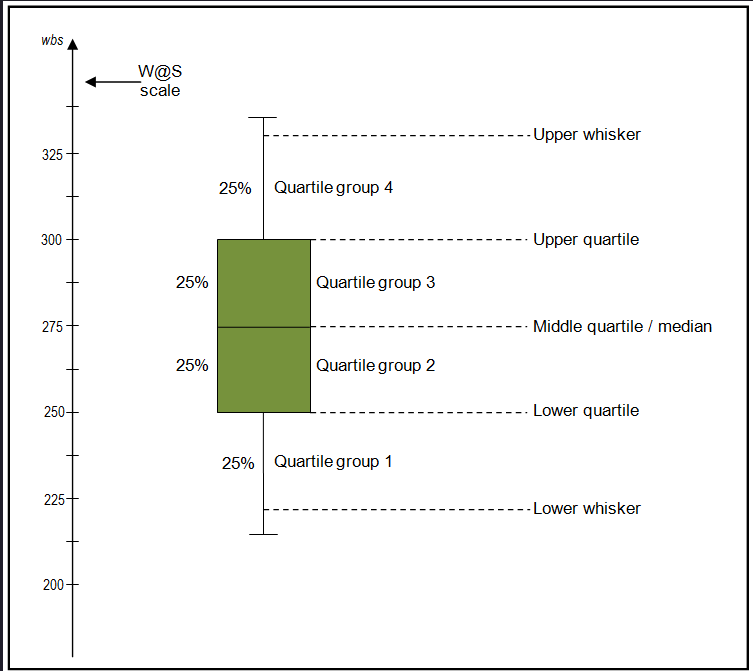

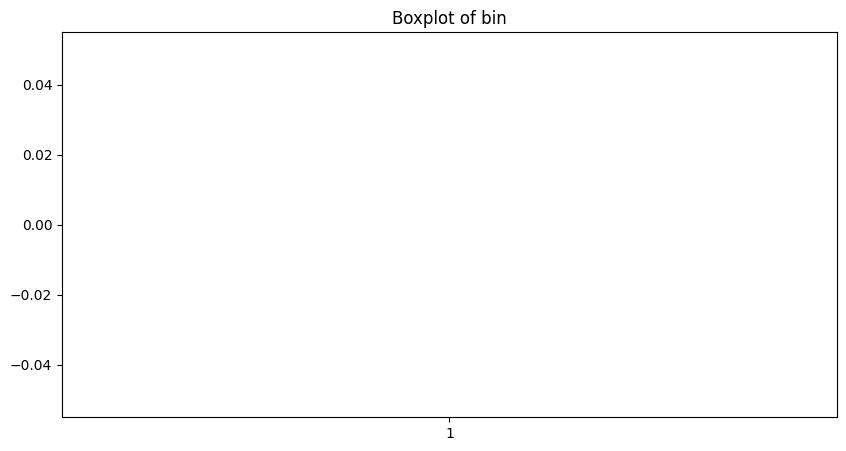

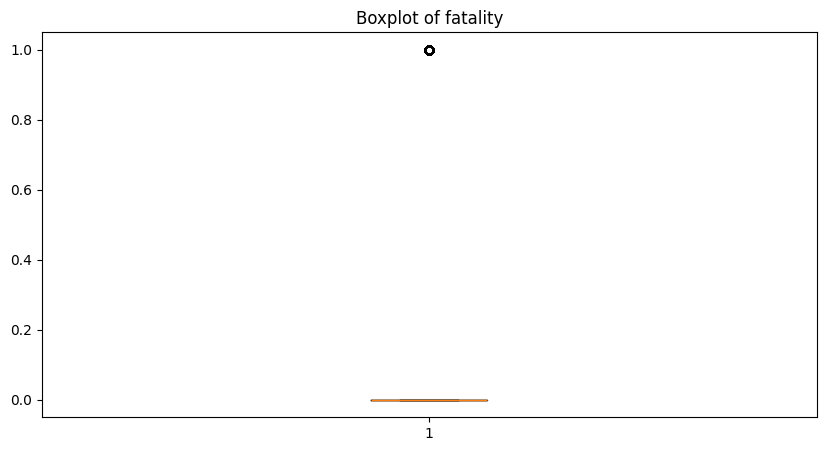

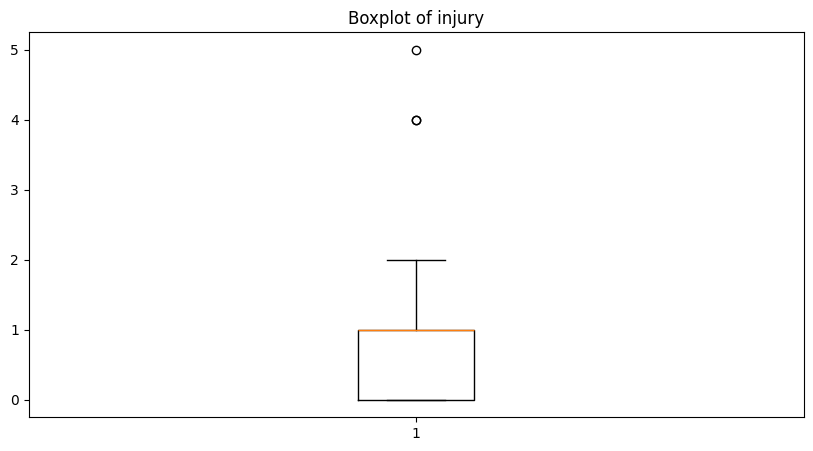

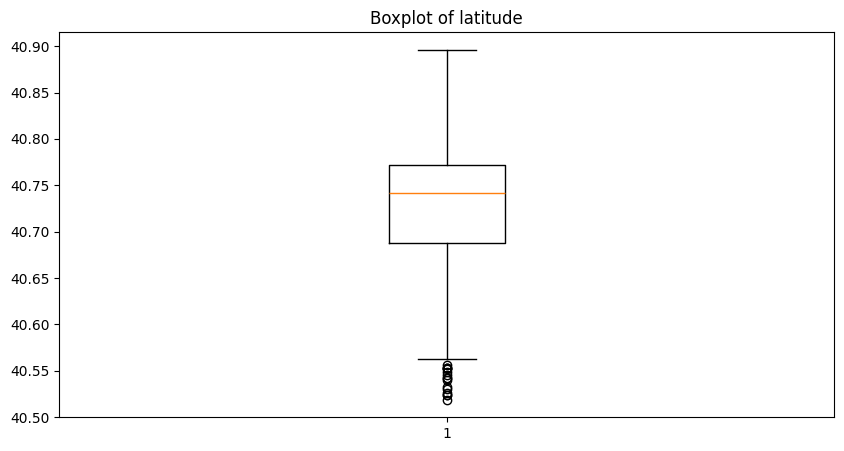

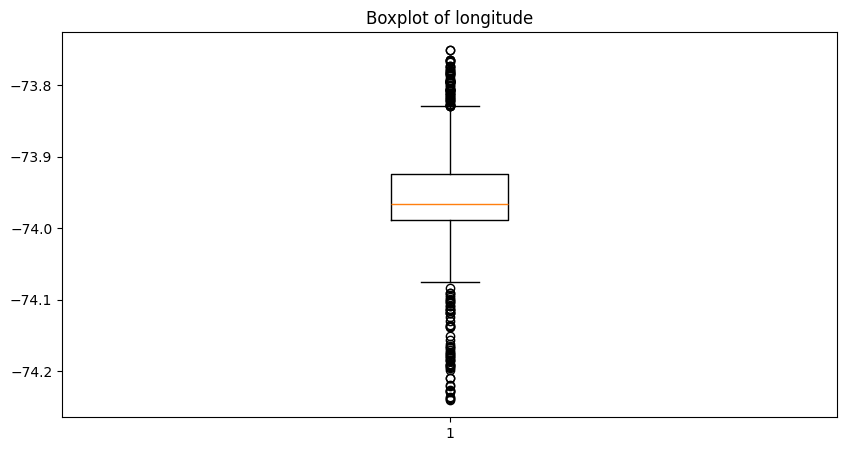

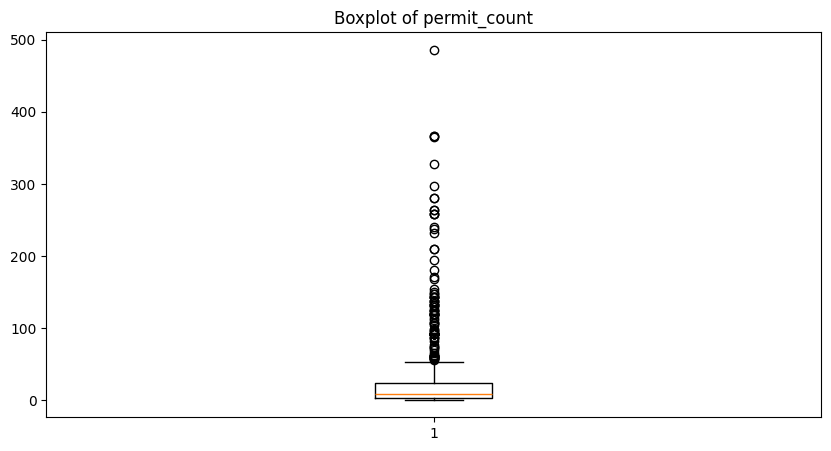

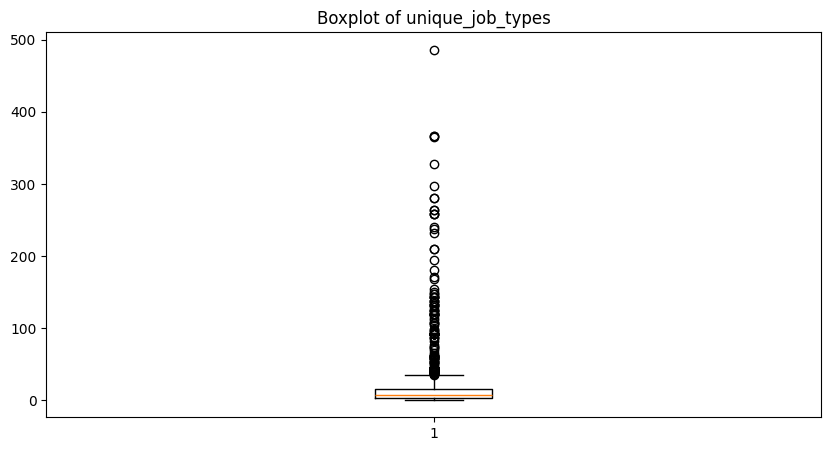

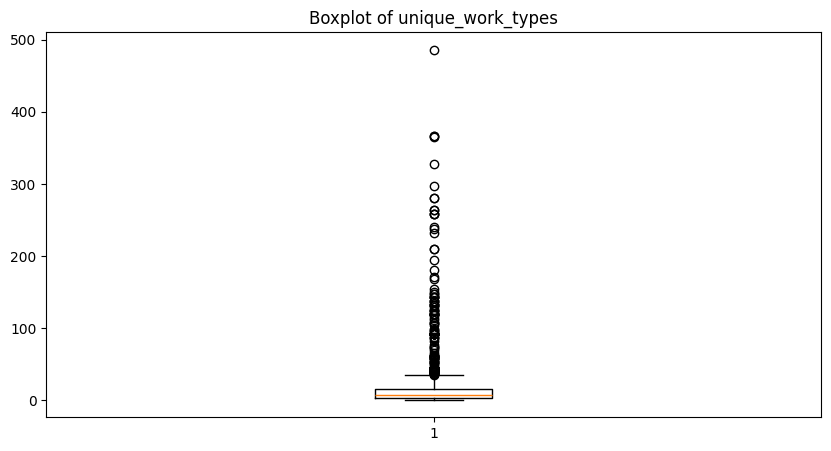

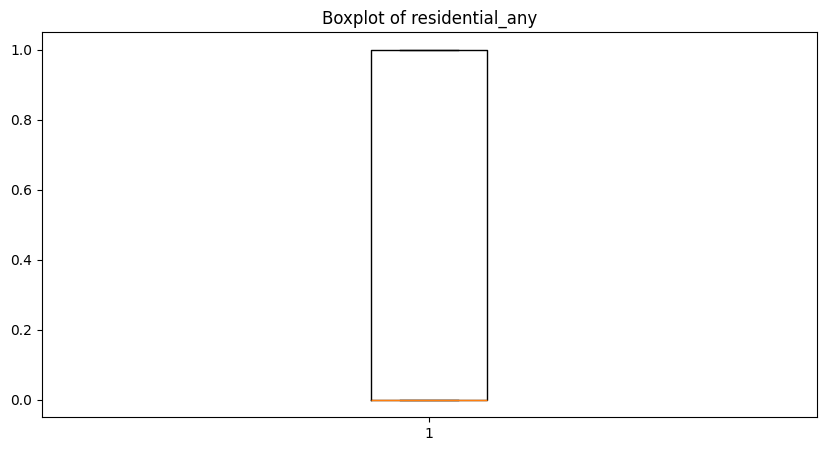

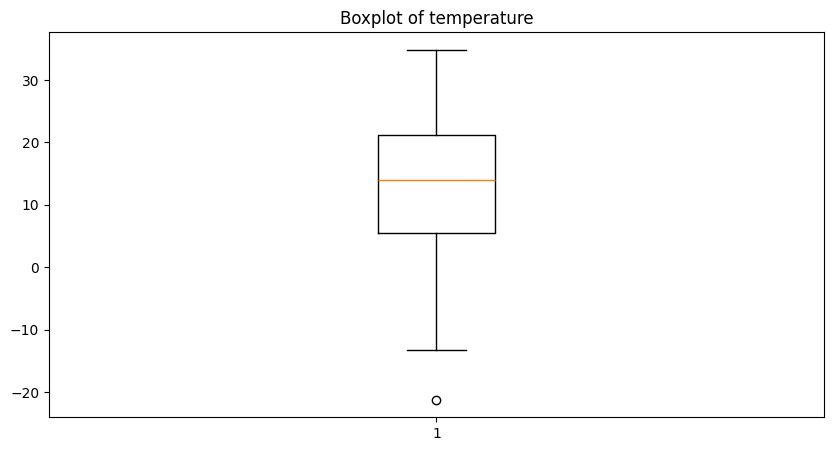

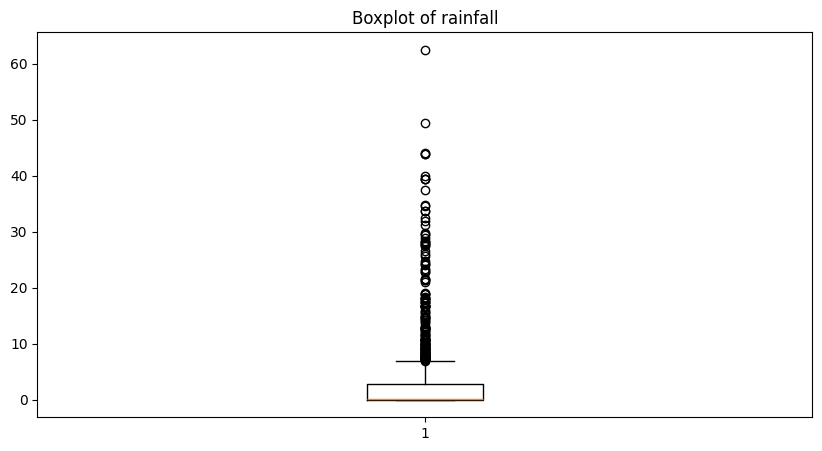

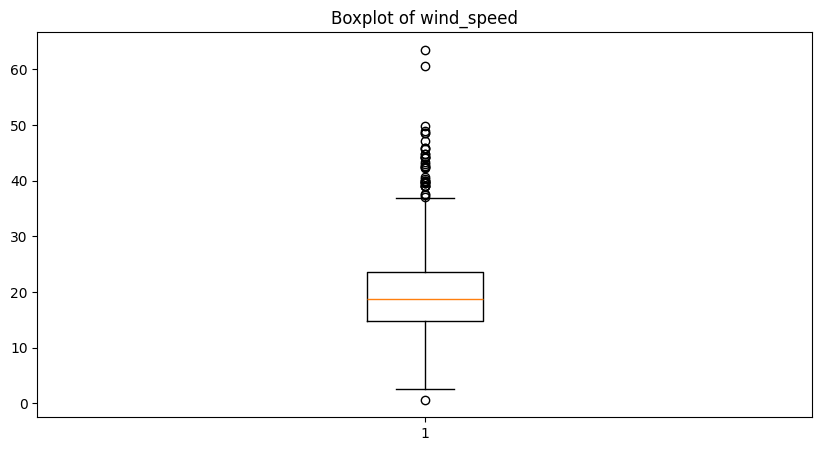

In [15]:
# detecting outliers in the numerical columns using boxplots
import matplotlib.pyplot as plt
num_cols = construction_data.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    plt.figure(figsize=(10, 5))
    plt.boxplot(construction_data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


Outliers in Fatality and Injury are retained because they represent real events of higher severity. Removing them would bias the model toward minor incidents and lose the signal from the most critical cases.

Coordinate outliers fall within NYC's valid geographic boundary, so they are retained. However, rows where coordinates were median-imputed should be flagged as they represent unknown locations, not real coordinates.

4. *Feature Engineering: adding new features in the data*

We will be adding the following features in the data to gain valuable insights:

1. Repeat Risk Rate
2. Day-based incident percentage

In [16]:
# computing weighted fatality index
construction_data['weighted_fatality_index'] = construction_data['fatality'] + 0.5 * construction_data['injury']

In [17]:
# creating a new feature called "Is_Repeat_Site" which indicates whether a construction site has had multiple incidents based on the "BIN" feature
bin_counts = construction_data['bin'].value_counts()
repeat_bins = bin_counts[bin_counts > 1].index
construction_data['is_repeat_site'] = construction_data['bin'].isin(repeat_bins).astype(int)

In [18]:
# creating a new feature called "Day_Incident_Pct" which indicates the percentage of incidents that occurred on each day of the week
construction_data['incident date'] = pd.to_datetime(construction_data['incident date'])
construction_data['incident_day'] = construction_data['incident date'].dt.day_name()

day_counts = construction_data['incident_day'].value_counts()
total = len(construction_data)
day_pct = (day_counts / total * 100)

construction_data['day_incident_pct'] = construction_data['incident_day'].map(day_pct)

In [19]:
# dropping the columns that are not useful for our analysis
construction_data.drop(columns=['incident date', 'incident_day'], inplace=True)
construction_data.drop(columns=['bin'], inplace=True)

In [20]:
# dropping unnecessary columns
construction_data.drop(columns=['postcode','community board','council district',
            'census tract (2020)',
            'neighborhood tabulation area (nta) (2020)'], inplace=True)

5. *Encoding the categorical columns*

In [21]:
# identifying the features that need encoding

construction_data['borough'].value_counts()

borough
Manhattan        471
Brooklyn         390
Queens           181
Bronx            164
Staten Island     47
Name: count, dtype: int64

In [22]:
construction_data['check2 description'].value_counts()

check2 description
Worker Fell                          477
Other Construction Related           429
Material Failure (Fell)              149
Mechanical Construction Equipment     78
Scaffold/Shoring Installations        51
Excavation/Soil Work                  37
Struck By                             32
Name: count, dtype: int64

In [23]:
construction_data['record type description'].value_counts()

record type description
Accident                958
Incident                256
Notification             33
Not DOB Jurisdiction      6
Name: count, dtype: int64

In [24]:
# encoding the categorical variables using one-hot encoding
construction_data['borough'] = construction_data['borough'].astype('category')
construction_data['check2 description'] = construction_data['check2 description'].astype('category')
construction_data['record type description'] = construction_data['record type description'].astype('category')
construction_data = pd.get_dummies(construction_data, columns=['borough', 'check2 description', 'record type description'], drop_first=True)
construction_data.head()


,fatality,injury,latitude,longitude,permit_count,unique_job_types,unique_work_types,residential_any,temperature,rainfall,...,borough_Staten Island,check2 description_Material Failure (Fell),check2 description_Mechanical Construction Equipment,check2 description_Other Construction Related,check2 description_Scaffold/Shoring Installations,check2 description_Struck By,check2 description_Worker Fell,record type description_Incident,record type description_Not DOB Jurisdiction,record type description_Notification
0,0,0,40.689238,-73.981765,3.0,3.0,3.0,1.0,18.400000,1.800000,...,False,False,False,True,False,False,False,True,False,False
1,1,2,40.632785,-74.113135,21.0,7.0,4.0,0.0,15.776278,24.466825,...,False,True,False,False,False,False,False,False,False,False
2,0,1,40.689356,-73.978567,27.0,27.0,27.0,1.0,18.600000,0.000000,...,False,False,False,False,False,False,True,False,False,False
3,0,0,40.722869,-73.855793,4.0,4.0,4.0,0.0,27.100000,0.000000,...,False,False,False,True,False,False,False,True,False,False
4,1,2,40.786907,-74.185831,32.0,4.0,5.0,0.0,21.463781,0.680663,...,False,False,False,False,False,True,False,False,False,False


In [25]:
# converting columns with boolean values to integers
bool_cols = ['permit_count', 'unique_job_types', 'unique_work_types', 'residential_any', 'temperature', 'rainfall', 'wind_speed', 'weighted_fatality_index', 'is_repeat_site', 'day_incident_pct', 'borough_Brooklyn', 'borough_Manhattan', 'borough_Queens', 'borough_Staten Island', 'check2 description_Material Failure (Fell)', 'check2 description_Mechanical Construction Equipment', 'check2 description_Other Construction Related', 'check2 description_Scaffold/Shoring Installations', 'check2 description_Struck By', 'check2 description_Worker Fell', 'record type description_Incident', 'record type description_Not DOB Jurisdiction', 'record type description_Notification']
for col in bool_cols:
    construction_data[col] = construction_data[col].astype(int)


In [26]:
# generating the final preprocessed data to a new CSV file
construction_data.to_csv('Preprocessed_Construction_Incidents.csv', index=False)

features like postcode and BIN may be numerical but they are fixed as in they are not calculated by a mathematical formula. As a result we can not normalize/standardize them.

The features that we will consider for normalization and standardization are as follows:

1. Latitude
2. Longitude
3. Weighted Fatality Index
4. Repeat Risk Rate
5. Day-based incident percentage

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the preprocessed (unstandardized) data
df = pd.read_csv('Preprocessed_Construction_Incidents.csv')

# Separate target and features FIRST
y = df['fatality'].astype(int)
X = df.drop(['fatality', 'injury', 'weighted_fatality_index'], axis=1, errors='ignore')

# Split BEFORE any scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Fit scaler on train only, then transform both splits separately
cols_to_scale = [
    'latitude', 'longitude', 'permit_count', 'unique_job_types',
    'unique_work_types', 'temperature', 'rainfall', 'wind_speed',
    'day_incident_pct'
]

scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print("Target distribution:\n", y.value_counts())
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Unique y values:", y.unique())

# =========================
# Save splits to disk
# =========================
train_df = X_train.copy()
train_df['fatality'] = y_train.values

test_df = X_test.copy()
test_df['fatality'] = y_test.values

train_df.to_csv('Standardized_Train.csv', index=False)
test_df.to_csv('Standardized_Test.csv', index=False)

print("Files saved: Standardized_Train.csv, Standardized_Test.csv")

Target distribution:
 fatality
0    1086
1     167
Name: count, dtype: int64
X_train shape: (1002, 24)
X_test shape: (251, 24)
Unique y values: [0 1]
Files saved: Standardized_Train.csv, Standardized_Test.csv


6. Data Augmentation

In [28]:
# checking for class imbalance for fatality 
construction_data['fatality'].value_counts()


fatality
0    1086
1     167
Name: count, dtype: int64

In [29]:
# import pandas as pd
# from imblearn.over_sampling import SMOTE
# from imblearn.pipeline import Pipeline as ImbPipeline
# from sklearn.model_selection import StratifiedKFold, cross_val_score
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import classification_report
# from sklearn.impute import SimpleImputer

# # =========================
# # 1. Load pre-split standardized data
# # =========================
# train_df = pd.read_csv('Standardized_Train.csv')
# test_df  = pd.read_csv('Standardized_Test.csv')

# X_train = train_df.drop('fatality', axis=1)
# y_train = train_df['fatality']

# X_test = test_df.drop('fatality', axis=1)
# y_test = test_df['fatality']

# # =========================
# # 2. Pipeline (SMOTE inside)
# # =========================
# pipeline = ImbPipeline([
#     ('imputer', SimpleImputer(strategy='median')),
#     ('smote', SMOTE(random_state=42, k_neighbors=5)),
#     ('classifier', KNeighborsClassifier(
#         n_neighbors=5,
#         metric='euclidean'
#     ))
# ])

# # =========================
# # 3. Cross-validation (on training data only)
# # =========================
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')

# print(f"Cross-validation F1 scores: {cv_scores}")
# print(f"Mean CV F1 score: {cv_scores.mean():.4f}")

# # =========================
# # 4. Final Model Training & Test Evaluation
# # =========================
# pipeline.fit(X_train, y_train)
# y_pred = pipeline.predict(X_test)

# print("\nTest Set Results (Unseen 20%):")
# print(classification_report(y_test, y_pred, target_names=['Non-Fatal', 'Fatal']))

# # =========================
# # 5. Exporting the Balanced Training Set
# # =========================
# imputer = SimpleImputer(strategy='median')
# X_train_imputed = imputer.fit_transform(X_train)

# smote_exporter = SMOTE(random_state=42, k_neighbors=5)
# X_train_resampled, y_train_resampled = smote_exporter.fit_resample(X_train_imputed, y_train)

# df_train_balanced = pd.DataFrame(X_train_resampled, columns=X_train.columns)
# df_train_balanced['fatality'] = y_train_resampled

# df_train_balanced.to_csv('Balanced_Training_Set_Only.csv', index=False)
# print(f"File Saved: Balanced_Training_Set_Only.csv")
# print(f"Training set rows (80% + SMOTE): {len(df_train_balanced)}")

# # =========================
# # 6. Exporting the Test Set
# # =========================
# df_test = X_test.copy()
# df_test['fatality'] = y_test.values

# df_test.to_csv('Test_Set_Only.csv', index=False)
# print(f"File Saved: Test_Set_Only.csv")
# print(f"Test set rows (unseen 20%): {len(df_test)}")

In [30]:
# generating the final preprocessed data to a new CSV file
# construction_data.to_csv('Preprocessed_Construction_Incidents.csv', index=False)

In [31]:
construction_data.shape

(1253, 27)

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the preprocessed (unstandardized) data
df = pd.read_csv('Preprocessed_Construction_Incidents.csv')

# Separate target and features FIRST
y = df['fatality'].astype(int)
X = df.drop(['fatality', 'injury', 'weighted_fatality_index'], axis=1, errors='ignore')

# Split BEFORE any scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Fit scaler on train only, then transform both splits separately
cols_to_scale = [
    'latitude', 'longitude', 'permit_count', 'unique_job_types',
    'unique_work_types', 'temperature', 'rainfall', 'wind_speed',
    'day_incident_pct'
]

scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print("Target distribution:\n", y.value_counts())
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Unique y values:", y.unique())

# =========================
# Save splits to disk
# =========================
train_df = X_train.copy()
train_df['fatality'] = y_train.values

test_df = X_test.copy()
test_df['fatality'] = y_test.values

train_df.to_csv('Standardized_Train_70.csv', index=False)
test_df.to_csv('Standardized_Test_30.csv', index=False)

print("Files saved: Standardized_Train_70.csv, Standardized_Test_30.csv")

Target distribution:
 fatality
0    1086
1     167
Name: count, dtype: int64
X_train shape: (877, 24)
X_test shape: (376, 24)
Unique y values: [0 1]
Files saved: Standardized_Train_70.csv, Standardized_Test_30.csv
